# Frankenstein Teacher Analysis
Evaluates whether hidden representation matrices natively encode properties aligned directly with original randomized classification vectors.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Determine runtime environment target. Default to full cache if run independently.
# To strictly handle Jupyter execution reliably, verify demo vs full.
cache_full = '../experiments/cache/frankenstein_teacher.json'
cache_demo = '../experiments/cache/frankenstein_teacher_demo.json'

cache_file = cache_full if os.path.exists(cache_full) else cache_demo
if os.path.exists(cache_file):
    with open(cache_file, 'r') as f:
        data = json.load(f).get('Data', {})
else:
    print('Cache file not found.')
    data = {}

In [2]:
def ci_95(arr):
    if len(arr) < 2:
        return 0.0
    return 1.96 * np.std(arr) / np.sqrt(len(arr))

if data:
    records = []
    for model_type, acc_list in data.items():
        records.append({
            'Model': model_type,
            'Mean Accuracy': np.mean(acc_list),
            'Error': ci_95(acc_list)
        })
    df = pd.DataFrame(records)
    from IPython.display import display
    display(df)

,Model,Mean Accuracy,Error
0,Teacher Baseline,0.94390,0.000936
1,Frankenstein Teacher,0.93245,0.003739


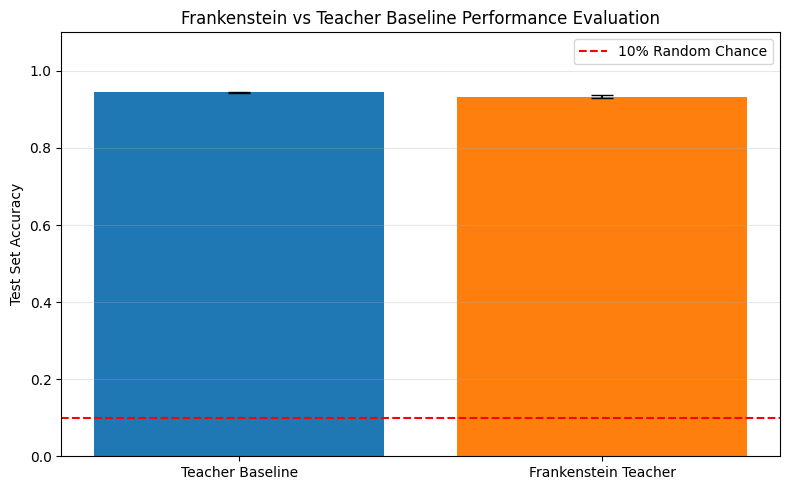

In [3]:
if data and 'df' in locals() and not df.empty:
    plt.figure(figsize=(8, 5))
    
    # Standard performance distributions mapped tightly as bar plots
    bars = plt.bar(df['Model'], df['Mean Accuracy'], yerr=df['Error'], capsize=8, color=['#1f77b4', '#ff7f0e'])
    
    # Baseline reference for blind statistical chance
    plt.axhline(0.10, ls='--', c='red', label='10% Random Chance')
    
    plt.ylabel('Test Set Accuracy')
    plt.title('Frankenstein vs Teacher Baseline Performance Evaluation')
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    os.makedirs('../docs/reports', exist_ok=True)
    plt.savefig('../docs/reports/frankenstein_chart.png', dpi=150)
    plt.show()